# Erasure or Probe Evasion? Class-Conditional Analysis and Fresh Adaptive Probes for PGA

**Purpose.** Two analyses on the released PGA-treated Pythia-70M checkpoint (LoRA adapter):

1. **Class-conditional activation analysis.** Diagnoses whether below-chance post-PGA probe
accuracy reflects (a) collapse of the mem/clean separation (class-conditional distributions
merge along the readout direction) or (b) inversion (distributions swap sides). Reports
per-layer class means, Cohen's d, ROC-AUC, and orientation-corrected accuracy
max(acc, 1-acc). Addresses Reviewer 2 Q1 and Reviewer 3 weakness ii / Q1.
2. **Fresh adaptive probe suite.** Probes trained from scratch **on post-PGA activations**
(the re-fitting attacker), across probe families (logistic regression, MLPs, RBF-SVM, kNN,
random forest), pooling schemes (last-token and mean-pooled), and context-augmented folds.
The honest robustness number is the worst-case orientation-corrected accuracy / AUC across
the suite. Addresses Reviewer 3 Q3, Reviewer 4 Q5/Q6, and the AC's erasure-vs-probe-
ineffectiveness bullet.

**Requirements.** The PGA LoRA adapter directory `pythia70m_pga_lora/`
(`adapter_config.json` + `adapter_model.safetensors` from the released
`reproducibility/checkpoints/`). On Kaggle: attach it as a dataset. On Colab: upload it or
mount Drive. The path-discovery cell below searches common locations. To preserve
double-blind anonymity, do not embed identifying repository URLs in materials shared with
reviewers.

Runs on CPU (about 10-20 minutes) or any GPU.


In [3]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/working')
OUT = '/kaggle/working' if IN_KAGGLE else ('/content' if IN_COLAB else '.')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers>=4.40', 'accelerate', 'scikit-learn', 'peft>=0.18'], check=True)
print('env:', 'kaggle' if IN_KAGGLE else ('colab' if IN_COLAB else 'local'), '| OUT =', OUT)


env: kaggle | OUT = /kaggle/working


In [4]:
import glob, json, gc
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_HF = 'EleutherAI/pythia-70m'
MAX_LEN = 128  # PGA producer notebooks use max_length=128

# ---- locate the PGA LoRA adapter ----
# Searches for adapter_model.safetensors itself, so it works whether the two adapter files
# are inside a pythia70m_pga_lora/ folder or sit at the root of a Kaggle dataset.
ADAPTER_PATH = None  # set manually if auto-discovery fails
if ADAPTER_PATH is None:
    hits = []
    for root in ['/kaggle/input', '/content', '/content/drive/MyDrive', '.']:
        if os.path.isdir(root):
            hits += glob.glob(os.path.join(root, '**', 'adapter_model.safetensors'), recursive=True)
    hits = [h for h in hits
            if os.path.exists(os.path.join(os.path.dirname(h), 'adapter_config.json'))]
    # prefer paths mentioning the expected folder name if several adapters are present
    hits.sort(key=lambda h: ('pythia70m_pga_lora' not in h, len(h)))
    if hits:
        ADAPTER_PATH = os.path.dirname(hits[0])
assert ADAPTER_PATH is not None, ('PGA LoRA adapter not found. Upload adapter_config.json + '
    'adapter_model.safetensors (from reproducibility/checkpoints/pythia70m_pga_lora/) and set '
    'ADAPTER_PATH to their directory.')
cfg_check = json.load(open(os.path.join(ADAPTER_PATH, 'adapter_config.json')))
assert cfg_check.get('base_model_name_or_path') == MODEL_HF, cfg_check.get('base_model_name_or_path')
print('adapter:', ADAPTER_PATH, '| device:', DEVICE)


adapter: /kaggle/input/datasets/<ANONYMIZED>/pythia70m-pga-lora | device: cuda


In [5]:
# Memorized / clean pools used to train PGA (pythia_memorized.json / pythia_clean.json,
# serialized verbatim). 7 paired sequences per class.
MEM_TEXTS = [
 "Copyright (c) 2016 The Linux Foundation. Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights",
 "GNU GENERAL PUBLIC LICENSE Version 2, June 1991 Copyright (C) 1989, 1991 Free Software Foundation, Inc., 51 Franklin Street, Fifth Floor, Boston, MA 02110-1301 USA Everyone is permitted to copy and distribute verbatim copies of this license document,",
 "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applicable law",
 "The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog.",
 "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat.",
 "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions",
 "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version."
]

CLEAN_TEXTS = [
 "The research team conducted experiments with three different sample groups to evaluate the effectiveness of the new treatment protocol. Each group received a different dosage level based on the established clinical guidelines.",
 "Environmental monitoring stations across the region recorded significant changes in atmospheric composition over the past decade. Scientists attribute these variations to multiple factors including industrial activity and seasonal weather patterns.",
 "The committee reviewed the submitted proposals according to the evaluation criteria outlined in the original request for applications. Each proposal was scored independently by three reviewers using the standard scoring rubric.",
 "Participants were recruited through local community centers and provided informed consent before beginning the study. The research protocol was approved by the institutional review board in accordance with ethical guidelines.",
 "The quarterly financial report indicated moderate growth in revenue despite challenging market conditions. Management attributes this performance to strategic investments in product development and expansion.",
 "Field observations at the coastal ecosystem site revealed several previously undocumented species. Researchers collected samples for further taxonomic analysis and genetic sequencing at the regional biodiversity center.",
 "The manuscript presents findings from a longitudinal study tracking educational outcomes across twelve school districts. Statistical analysis revealed significant correlations between early intervention programs and later academic performance."
]

CONTEXTS = [
 "Here is a passage: ",
 "A document contains: ",
 "Someone shared: ",
 "I copied this: ",
 "From a book: ",
 "Below is a snippet: ",
 "The document begins: ",
 "An archived message: ",
 "The paragraph states: ",
 "A clipboard entry: ",
 "The transcript records: ",
 "An earlier note: ",
 "The preface reads: ",
 "A footnote provides: ",
 "According to record: ",
 "The memo opens: ",
 "In the margin: ",
 "The cover letter: ",
 "The archive entry: ",
 "A clipping mentions: ",
 "The letter continues: ",
 "The dispatch read: ",
 "The annotation: ",
 "The bulletin noted: "
]  # 24 neutral prefixes, for context augmentation
assert len(MEM_TEXTS) == len(CLEAN_TEXTS) == 7 and len(CONTEXTS) == 24
N_PAIRS = 7
# Archived per-layer leave-one-pair-out probe values for this checkpoint (sanity targets):
EXPECTED_BASE = [0.643, 0.714, 0.786, 0.857, 0.857, 0.929, 0.929]
EXPECTED_PGA  = [0.643, 0.714, 0.571, 0.286, 0.429, 0.286, 0.143]


In [8]:
tok = AutoTokenizer.from_pretrained(MODEL_HF)
base = AutoModelForCausalLM.from_pretrained(MODEL_HF, torch_dtype=torch.float32).to(DEVICE).eval()
pga_backbone = AutoModelForCausalLM.from_pretrained(MODEL_HF, torch_dtype=torch.float32)
pga = PeftModel.from_pretrained(pga_backbone, ADAPTER_PATH).to(DEVICE).eval()
N_DEPTHS = base.config.num_hidden_layers + 1  # 7 for pythia-70m

@torch.no_grad()
def acts(model, text, pooling='last', max_len=MAX_LEN):
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_len).input_ids.to(DEVICE)
    hs = model(ids, output_hidden_states=True).hidden_states
    if pooling == 'last':
        return np.stack([h[0, -1].float().cpu().numpy() for h in hs])
    return np.stack([h[0].float().mean(0).cpu().numpy() for h in hs])  # mean over tokens

def extract_raw(model, pooling='last'):
    """Raw texts, no context: (7, D, d) per class - the producer-notebook protocol."""
    A = np.stack([acts(model, t, pooling) for t in MEM_TEXTS])
    B = np.stack([acts(model, t, pooling) for t in CLEAN_TEXTS])
    return A, B

def extract_ctx(model, pooling='last'):
    """Context-augmented: (7, 24, D, d) per class."""
    A = np.stack([np.stack([acts(model, c + t, pooling) for c in CONTEXTS]) for t in MEM_TEXTS])
    B = np.stack([np.stack([acts(model, c + t, pooling) for c in CONTEXTS]) for t in CLEAN_TEXTS])
    return A, B

print('extracting raw activations (base, PGA)...')
BASE_MEM, BASE_CLN = extract_raw(base)
PGA_MEM, PGA_CLN = extract_raw(pga)
print('extracting context-augmented activations (base, PGA)...')
BASE_MEM_CTX, BASE_CLN_CTX = extract_ctx(base)
PGA_MEM_CTX, PGA_CLN_CTX = extract_ctx(pga)
print('shapes:', BASE_MEM.shape, BASE_MEM_CTX.shape)


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


extracting raw activations (base, PGA)...
extracting context-augmented activations (base, PGA)...
shapes: (7, 7, 512) (7, 24, 7, 512)


In [7]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


layer | base acc (exp) | PGA acc (exp) | PGA concordance | PGA flipped-acc
  L0  |  0.643 (0.643)  |  0.643 (0.643)  |  0.786  |  0.643
  L1  |  0.714 (0.714)  |  0.714 (0.714)  |  0.714  |  0.714
  L2  |  0.786 (0.786)  |  0.571 (0.571)  |  0.571  |  0.571
  L3  |  0.857 (0.857)  |  0.286 (0.286)  |  0.000  |  0.714
  L4  |  0.857 (0.857)  |  0.429 (0.429)  |  0.000  |  0.571
  L5  |  0.929 (0.929)  |  0.286 (0.286)  |  0.000  |  0.714
  L6  |  0.929 (0.929)  |  0.143 (0.143)  |  0.000  |  0.857

If this-run values deviate from expected by more than ~0.15 at any layer,
resolve the protocol mismatch before interpreting Parts B/C.


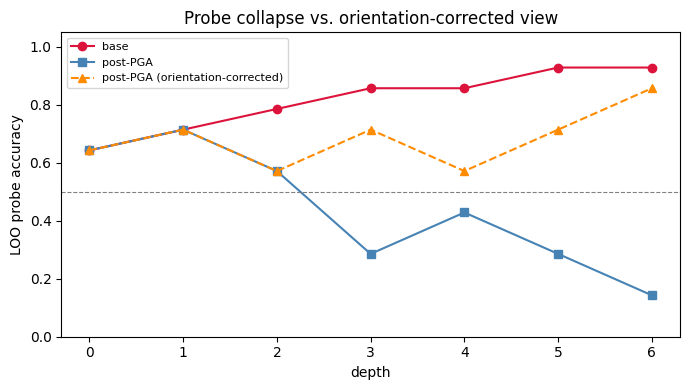

In [9]:
# ---- Part A: replicate the archived leave-one-pair-out probe values ----
def pair_probe(A, B, depth):
    """Leave-one-pair-out probe. Concordance = per-fold check that the held-out memorized
    item scores above its paired clean item (fold-wise ranking; avoids pooling decision
    values across folds with different scales)."""
    fold_acc, fold_conc = [], []
    for i in range(N_PAIRS):
        tr = [j for j in range(N_PAIRS) if j != i]
        Xtr = np.concatenate([A[tr, depth], B[tr, depth]])
        ytr = np.concatenate([np.ones(len(tr)), np.zeros(len(tr))])
        Xte = np.stack([A[i, depth], B[i, depth]]); yte = np.array([1.0, 0.0])
        sc = StandardScaler().fit(Xtr)
        clf = LogisticRegression(C=1.0, max_iter=10000, random_state=SEED).fit(sc.transform(Xtr), ytr)
        fold_acc.append(float(clf.score(sc.transform(Xte), yte)))
        dm, dc = clf.decision_function(sc.transform(Xte))
        fold_conc.append(1.0 if dm > dc else (0.5 if dm == dc else 0.0))
    return float(np.mean(fold_acc)), float(np.mean(fold_conc))

print('layer | base acc (exp) | PGA acc (exp) | PGA concordance | PGA flipped-acc')
partA = []
for d in range(N_DEPTHS):
    ab, cb = pair_probe(BASE_MEM, BASE_CLN, d)
    ap, cp = pair_probe(PGA_MEM, PGA_CLN, d)
    flip = max(ap, 1 - ap)
    partA.append({'layer': d, 'base_acc': ab, 'base_concordance': cb, 'pga_acc': ap,
                  'pga_concordance': cp, 'pga_flipped': flip})
    print(f'  L{d}  |  {ab:.3f} ({EXPECTED_BASE[d]:.3f})  |  {ap:.3f} ({EXPECTED_PGA[d]:.3f})'
          f'  |  {cp:.3f}  |  {flip:.3f}')
print('\nIf this-run values deviate from expected by more than ~0.15 at any layer,')
print('resolve the protocol mismatch before interpreting Parts B/C.')

# Figure: per-layer probe accuracy, base vs post-PGA, with orientation-corrected overlay
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.dpi'] = 600
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(range(N_DEPTHS))
ax.plot(xs, [r['base_acc'] for r in partA], marker='o', color='crimson', label='base')
ax.plot(xs, [r['pga_acc'] for r in partA], marker='s', color='steelblue', label='post-PGA')
ax.plot(xs, [r['pga_flipped'] for r in partA], marker='^', ls='--', color='darkorange',
        label='post-PGA (orientation-corrected)')
ax.axhline(0.5, color='gray', lw=0.8, ls='--')
ax.set_xlabel('depth'); ax.set_ylabel('LOO probe accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('Probe collapse vs. orientation-corrected view'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_probe_collapse_corrected.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_probe_collapse_corrected.pdf'), bbox_inches='tight')
plt.show()


L0: d(base,w_pre)=+1.49  d(PGA,w_pre)=+1.49  d(PGA,w_post)=+0.92  -> collapsed
L1: d(base,w_pre)=+9.09  d(PGA,w_pre)=+11.24  d(PGA,w_post)=+0.72  -> collapsed
L2: d(base,w_pre)=+11.95  d(PGA,w_pre)=+2.61  d(PGA,w_post)=+0.07  -> collapsed
L3: d(base,w_pre)=+20.45  d(PGA,w_pre)=-0.76  d(PGA,w_post)=-4.04  -> readable-by-refit
L4: d(base,w_pre)=+17.10  d(PGA,w_pre)=-0.58  d(PGA,w_post)=-1.99  -> collapsed
L5: d(base,w_pre)=+19.64  d(PGA,w_pre)=+1.44  d(PGA,w_post)=-1.93  -> collapsed
L6: d(base,w_pre)=+12.01  d(PGA,w_pre)=-0.92  d(PGA,w_post)=-2.11  -> readable-by-refit


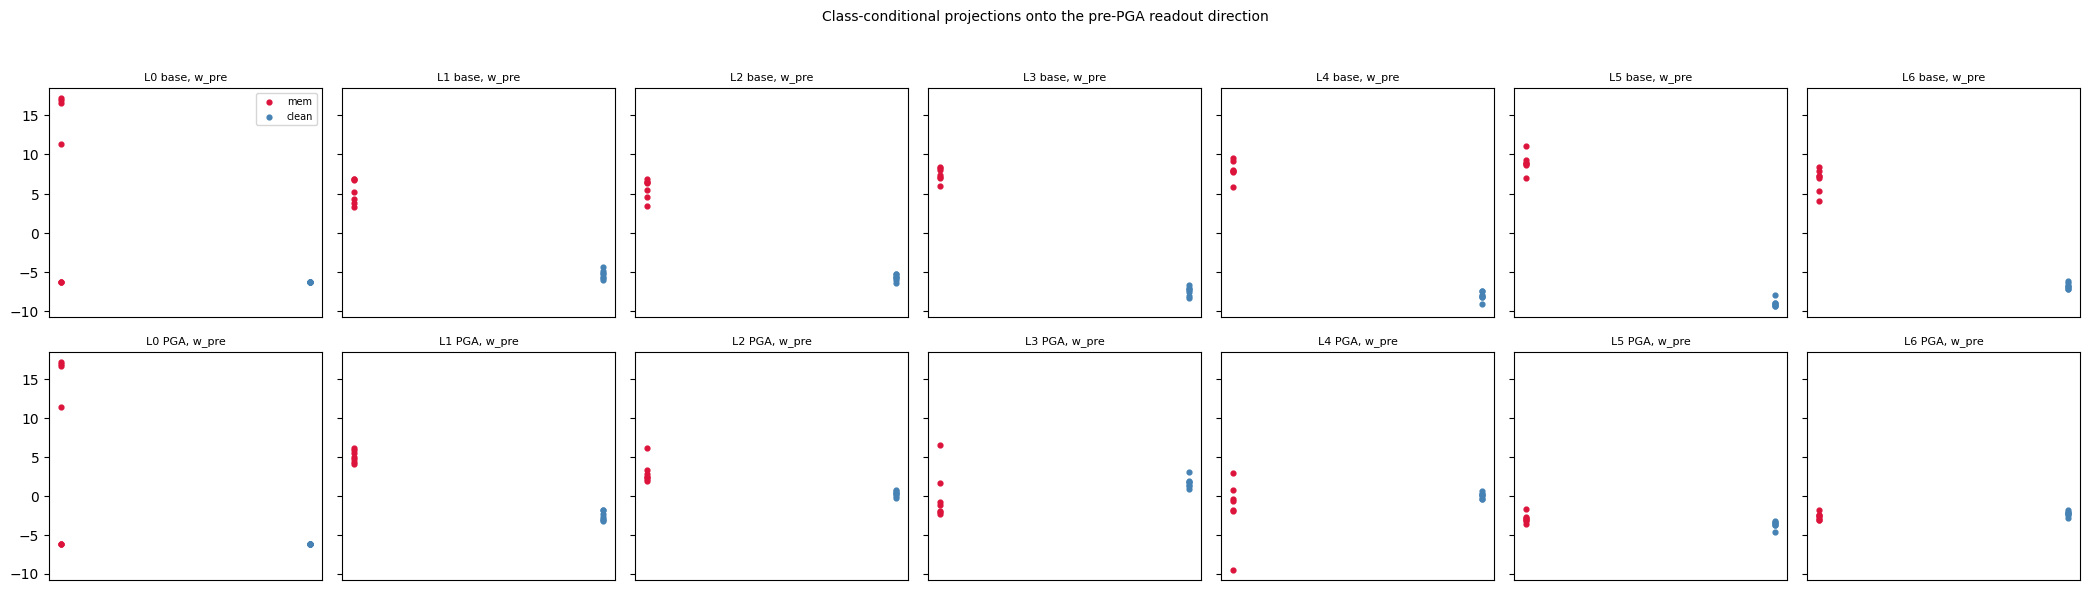

In [10]:
# ---- Part B: class-conditional analysis along readout directions ----
# For each layer: fit the probe direction on BASE activations (w_pre) and on PGA activations
# (w_post, the re-fit attacker direction), then examine the class-conditional distributions of
# the scalar projections for base and PGA models. Diagnosis per layer:
#   collapsed: |Cohen's d| small along both directions -> information removed (to this probe)
#   inverted:  mem/clean means swap sign along w_pre -> information present, orientation flipped
#   readable:  |d| large along w_post -> re-fit attacker still reads the signal
def fit_direction(A, B, depth):
    X = np.concatenate([A[:, depth], B[:, depth]])
    y = np.concatenate([np.ones(len(A)), np.zeros(len(B))])
    sc = StandardScaler().fit(X)
    clf = LogisticRegression(C=1.0, max_iter=10000, random_state=SEED).fit(sc.transform(X), y)
    w = clf.coef_[0] / np.linalg.norm(clf.coef_[0])
    return sc, w

def heldout_refit_d(A, B, depth):
    """Held-out Cohen's d along re-fit directions: for each left-out pair, fit the readout
    on the remaining 6 pairs and project the held-out pair. Avoids the in-sample circularity
    of fitting and evaluating the re-fit direction on the same 14 points (n << d_model)."""
    proj_m, proj_c = [], []
    for i in range(len(A)):
        tr = [j for j in range(len(A)) if j != i]
        sc, w = fit_direction(A[tr], B[tr], depth)
        proj_m.append(((sc.transform(A[i:i+1, depth]) @ w)[0]).item())
        proj_c.append(((sc.transform(B[i:i+1, depth]) @ w)[0]).item())
    return cohens_d(np.array(proj_m), np.array(proj_c))

def proj(sc, w, A, depth):
    return sc.transform(A[:, depth]) @ w

def cohens_d(a, b):
    sp = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return float((np.mean(a) - np.mean(b)) / sp) if sp > 0 else 0.0

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.dpi'] = 600

partB = []
fig, axes = plt.subplots(2, N_DEPTHS, figsize=(3 * N_DEPTHS, 6), sharey='row')
for d in range(N_DEPTHS):
    sc_pre, w_pre = fit_direction(BASE_MEM, BASE_CLN, d)
    pre_m, pre_c = proj(sc_pre, w_pre, BASE_MEM, d), proj(sc_pre, w_pre, BASE_CLN, d)
    pga_m, pga_c = proj(sc_pre, w_pre, PGA_MEM, d), proj(sc_pre, w_pre, PGA_CLN, d)
    d_pre = cohens_d(pre_m, pre_c)      # base model along w_pre (reference; w_pre is
                                        # in-sample for the base model - reference only)
    d_pga_wpre = cohens_d(pga_m, pga_c) # PGA acts along the BASE-fit direction: out-of-sample
                                        # w.r.t. PGA, valid inversion check
    d_pga_wpost = heldout_refit_d(PGA_MEM, PGA_CLN, d)  # held-out re-fit readability
    # Composed diagnosis: inversion and re-fit readability are independent properties.
    # Thresholds are calibrated to the small-n null: for a FIXED direction with n=7/class the
    # null sd of Cohen's d is ~0.53 (threshold 1.0 ~ 2 sd); for the held-out RE-FIT direction
    # at n=7 pairs, d_model=512, the null |d| reaches ~1.6-2.1 (measured over 20 synthetic
    # seeds), so only |d| >= 2.0 counts as re-fit readability here. Part C's fold-based
    # fresh-probe suite is the authoritative readability evidence; this flag is descriptive.
    flags = []
    if d_pga_wpre < -1.0: flags.append('inverted-along-w_pre')
    if abs(d_pga_wpost) >= 2.0: flags.append('readable-by-refit')
    if not flags: flags.append('collapsed')
    diag = '+'.join(flags)
    partB.append({'layer': d, 'd_base_wpre': d_pre, 'd_pga_wpre': d_pga_wpre,
                  'd_pga_wpost': d_pga_wpost, 'diagnosis': diag})
    for row, (m_, c_, ttl) in enumerate([
            ((pre_m, pre_c), None, f'L{d} base, w_pre'),
            ((pga_m, pga_c), None, f'L{d} PGA, w_pre')]):
        ax = axes[row][d]
        mm, cc = m_
        ax.scatter(np.zeros_like(mm), mm, c='crimson', s=12, label='mem')
        ax.scatter(np.ones_like(cc), cc, c='steelblue', s=12, label='clean')
        ax.set_xticks([]); ax.set_title(ttl, fontsize=8)
    print(f'L{d}: d(base,w_pre)={d_pre:+.2f}  d(PGA,w_pre)={d_pga_wpre:+.2f}  '
          f'd(PGA,w_post)={d_pga_wpost:+.2f}  -> {diag}')
axes[0][0].legend(fontsize=7)
plt.suptitle('Class-conditional projections onto the pre-PGA readout direction', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(OUT, 'fig_class_conditional_projections.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_class_conditional_projections.pdf'), bbox_inches='tight')
plt.show()


Fresh probes on BASE activations (reference):
  LR C=1.0 s42       flipped-acc by layer: 0.79 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  LR C=0.1 s13       flipped-acc by layer: 0.64 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  LR C=10 s99        flipped-acc by layer: 0.79 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  MLP[16] s42        flipped-acc by layer: 0.57 0.57 0.64 0.77 0.72 0.80 0.78  | worst L2-L6: 0.804
  MLP[32,16] s7      flipped-acc by layer: 0.71 0.71 0.71 0.91 0.79 0.78 0.60  | worst L2-L6: 0.911
  RBF-SVM C=1        flipped-acc by layer: 0.79 0.86 0.93 0.96 0.93 0.93 0.93  | worst L2-L6: 0.955
  kNN k=5            flipped-acc by layer: 0.50 0.50 0.57 0.64 0.71 0.93 0.79  | worst L2-L6: 0.929
  RandForest s42     flipped-acc by layer: 0.79 0.86 0.85 0.86 0.93 0.93 0.93  | worst L2-L6: 0.929

Fresh probes on POST-PGA activations:
  LR C=1.0 s42       flipped-acc by layer: 0.79 0.71 0.62 0.71 0.57 0.64 0.90  | worst L2-L6: 0.896
  LR C=0.1 s13 

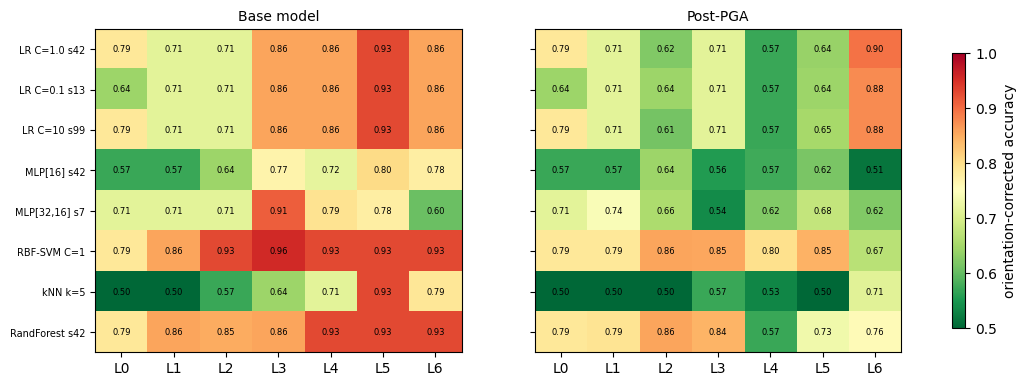

In [11]:
# ---- Part C: fresh adaptive probe suite trained ON post-PGA activations ----
# Context-augmented leave-one-pair-out folds: train on 6 pairs x 24 contexts (288 points),
# test on the held-out pair's 48 points. Report accuracy, AUC, orientation-corrected accuracy.
def make_clf(spec):
    kind, kw = spec
    if kind == 'lr':  return LogisticRegression(max_iter=5000, **kw)
    if kind == 'mlp': return MLPClassifier(max_iter=2000, early_stopping=True, **kw)
    if kind == 'svm': return SVC(kernel='rbf', probability=False, **kw)
    if kind == 'knn': return KNeighborsClassifier(**kw)
    if kind == 'rf':  return RandomForestClassifier(n_estimators=200, **kw)

PROBE_SUITE = {
    'LR C=1.0 s42':      ('lr',  {'C': 1.0, 'random_state': 42}),
    'LR C=0.1 s13':      ('lr',  {'C': 0.1, 'random_state': 13}),
    'LR C=10 s99':       ('lr',  {'C': 10.0, 'random_state': 99}),
    'MLP[16] s42':       ('mlp', {'hidden_layer_sizes': (16,), 'random_state': 42}),
    'MLP[32,16] s7':     ('mlp', {'hidden_layer_sizes': (32, 16), 'random_state': 7}),
    'RBF-SVM C=1':       ('svm', {'C': 1.0}),
    'kNN k=5':           ('knn', {'n_neighbors': 5}),
    'RandForest s42':    ('rf',  {'random_state': 42}),
}

def fresh_probe_eval(A_ctx, B_ctx, depth, spec):
    """Context-augmented leave-one-pair-out evaluation. AUC is computed per fold and
    averaged (decision scales are not comparable across folds, esp. for SVM)."""
    accs, aucs = [], []
    for i in range(N_PAIRS):
        tr = [j for j in range(N_PAIRS) if j != i]
        Xtr = np.concatenate([A_ctx[tr, :, depth].reshape(-1, A_ctx.shape[-1]),
                              B_ctx[tr, :, depth].reshape(-1, B_ctx.shape[-1])])
        ytr = np.concatenate([np.ones(len(tr) * 24), np.zeros(len(tr) * 24)])
        Xte = np.concatenate([A_ctx[i, :, depth], B_ctx[i, :, depth]])
        yte = np.concatenate([np.ones(24), np.zeros(24)])
        sc = StandardScaler().fit(Xtr)
        clf = make_clf(spec).fit(sc.transform(Xtr), ytr)
        pred = clf.predict(sc.transform(Xte))
        accs.append(float(np.mean(pred == yte)))
        if hasattr(clf, 'decision_function'):
            dec = clf.decision_function(sc.transform(Xte))
        else:
            dec = clf.predict_proba(sc.transform(Xte))[:, 1]
        aucs.append(float(roc_auc_score(yte, dec)))
    acc = float(np.mean(accs))
    auc = float(np.mean(aucs))
    return {'acc': acc, 'auc': auc, 'flipped_acc': max(acc, 1 - acc),
            'flipped_auc': max(auc, 1 - auc)}

def run_suite(A_ctx, B_ctx, label):
    out = {}
    print(f'{label}:')
    for pname, spec in PROBE_SUITE.items():
        per_layer = [fresh_probe_eval(A_ctx, B_ctx, d, spec) for d in range(N_DEPTHS)]
        out[pname] = per_layer
        worst = max(r['flipped_acc'] for r in per_layer[2:])  # mem-relevant layers L2+
        row = ' '.join(f"{r['flipped_acc']:.2f}" for r in per_layer)
        print(f'  {pname:18s} flipped-acc by layer: {row}  | worst L2-L6: {worst:.3f}')
    return out

# Reference: the same fresh-probe suite on the UNEDITED base model (what an attacker gets
# before PGA). The rebuttal number is the base-vs-post-PGA contrast, not the raw value.
suite_base = run_suite(BASE_MEM_CTX, BASE_CLN_CTX, 'Fresh probes on BASE activations (reference)')
print()
suite_pga = run_suite(PGA_MEM_CTX, PGA_CLN_CTX, 'Fresh probes on POST-PGA activations')

# Mean-pooled variant for the two strongest probe families (pooling-scheme robustness).
# Run on BOTH base and post-PGA so the worst-case maxima compare the same probe count.
MP_PROBES = ['LR C=1.0 s42', 'MLP[32,16] s7']
print('\nMean-pooled variants:')
PGA_MEM_CTX_MP, PGA_CLN_CTX_MP = extract_ctx(pga, pooling='mean')
BASE_MEM_CTX_MP, BASE_CLN_CTX_MP = extract_ctx(base, pooling='mean')
suite_pga_mp, suite_base_mp = {}, {}
for pname in MP_PROBES:
    for tag, (Am, Bm), store in [('base', (BASE_MEM_CTX_MP, BASE_CLN_CTX_MP), suite_base_mp),
                                 ('PGA', (PGA_MEM_CTX_MP, PGA_CLN_CTX_MP), suite_pga_mp)]:
        per_layer = [fresh_probe_eval(Am, Bm, d, PROBE_SUITE[pname]) for d in range(N_DEPTHS)]
        store[pname + ' (mean-pool)'] = per_layer
        worst = max(r['flipped_acc'] for r in per_layer[2:])
        row = ' '.join(f"{r['flipped_acc']:.2f}" for r in per_layer)
        print(f'  [{tag}] {pname:18s} flipped-acc by layer: {row}  | worst L2-L6: {worst:.3f}')

# Permutation-null calibration for the worst-case statistic. max(acc, 1-acc) is biased above
# 0.5 under the null, and taking the max over a probe suite compounds that bias; the observed
# worst-case is only interpretable against the same statistic computed under label permutation.
def fresh_probe_eval_null(A_ctx, B_ctx, depth, spec, null_seed):
    rng = np.random.default_rng(null_seed)
    accs = []
    for i in range(N_PAIRS):
        tr = [j for j in range(N_PAIRS) if j != i]
        Xtr = np.concatenate([A_ctx[tr, :, depth].reshape(-1, A_ctx.shape[-1]),
                              B_ctx[tr, :, depth].reshape(-1, B_ctx.shape[-1])])
        ytr = rng.permutation(np.concatenate([np.ones(len(tr) * 24), np.zeros(len(tr) * 24)]))
        Xte = np.concatenate([A_ctx[i, :, depth], B_ctx[i, :, depth]])
        yte = np.concatenate([np.ones(24), np.zeros(24)])
        sc = StandardScaler().fit(Xtr)
        clf = make_clf(spec).fit(sc.transform(Xtr), ytr)
        accs.append(float(np.mean(clf.predict(sc.transform(Xte)) == yte)))
    a = float(np.mean(accs))
    return max(a, 1 - a)

N_NULL_SEEDS = 3
print('\nPermutation-null calibration of the worst-case statistic (post-PGA activations):')
null_worst = []
for ns_ in range(N_NULL_SEEDS):
    vals = [fresh_probe_eval_null(PGA_MEM_CTX, PGA_CLN_CTX, d, spec, null_seed=1000 + 31 * ns_ + d)
            for pname, spec in PROBE_SUITE.items() for d in range(2, N_DEPTHS)]
    null_worst.append(max(vals))
    print(f'  null seed {ns_}: worst-case flipped-acc over suite x L2-L6 = {null_worst[-1]:.3f}')
NULL_WORST_MEAN = float(np.mean(null_worst))
print(f'  null worst-case mean over {N_NULL_SEEDS} seeds: {NULL_WORST_MEAN:.3f}')
print('  Observed worst-case values at or below this null level are indistinguishable from')
print('  chance under probe-suite maximization; only exceedances above it indicate readability.')

# Figure: probe-family x layer heatmaps of orientation-corrected accuracy, base vs post-PGA
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
pnames = list(PROBE_SUITE)
M_base = np.array([[suite_base[p][d]['flipped_acc'] for d in range(N_DEPTHS)] for p in pnames])
M_pga = np.array([[suite_pga[p][d]['flipped_acc'] for d in range(N_DEPTHS)] for p in pnames])
for ax, M, ttl in [(axes[0], M_base, 'Base model'), (axes[1], M_pga, 'Post-PGA')]:
    im = ax.imshow(M, vmin=0.5, vmax=1.0, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(N_DEPTHS)); ax.set_xticklabels([f'L{d}' for d in range(N_DEPTHS)])
    ax.set_title(ttl, fontsize=10)
    for r_ in range(M.shape[0]):
        for c_ in range(M.shape[1]):
            ax.text(c_, r_, f'{M[r_, c_]:.2f}', ha='center', va='center', fontsize=6)
axes[0].set_yticks(range(len(pnames))); axes[0].set_yticklabels(pnames, fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.85, label='orientation-corrected accuracy')
plt.savefig(os.path.join(OUT, 'fig_fresh_probe_heatmap.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_fresh_probe_heatmap.pdf'), bbox_inches='tight')
plt.show()


WORST-CASE orientation-corrected accuracy by layer (fresh probes, all poolings):
layer |  base  | post-PGA | post-PGA AUC
  L0  |  0.929 |  0.929   |  1.000
  L1  |  0.955 |  0.932   |  1.000
  L2  |  0.929 |  0.929   |  0.987
  L3  |  0.955 |  0.914   |  1.000
  L4  |  0.929 |  0.940   |  1.000
  L5  |  0.997 |  0.955   |  1.000
  L6  |  0.929 |  0.926   |  1.000

Headline contrast for the response (mem-relevant layers L2-L6):
  base worst-case 0.997  vs  post-PGA worst-case 0.955  vs  permutation-null worst-case 0.841


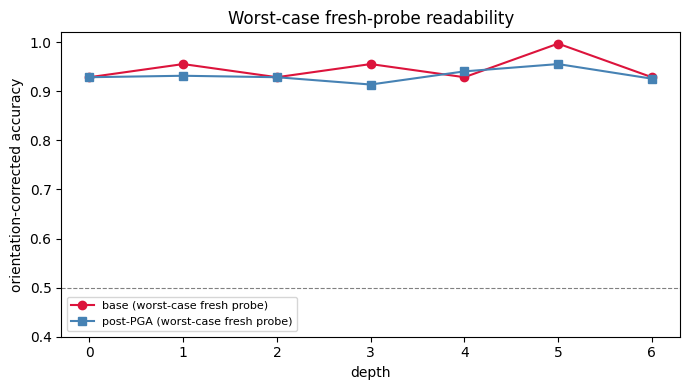

Saved: /kaggle/working/erasure_vs_evasion_results.json + fig_worst_case_fresh_probe.{png,pdf}


In [12]:
# ---- Part D: rebuttal-ready summary + JSON + figure ----
pga_suites = {**suite_pga, **suite_pga_mp}
base_suites = {**suite_base, **suite_base_mp}  # same probe count as pga_suites
worst_by_layer = [max(s[d]['flipped_acc'] for s in pga_suites.values()) for d in range(N_DEPTHS)]
worst_auc_by_layer = [max(s[d]['flipped_auc'] for s in pga_suites.values()) for d in range(N_DEPTHS)]
base_worst_by_layer = [max(s[d]['flipped_acc'] for s in base_suites.values()) for d in range(N_DEPTHS)]
summary = {
    'partA_pair_probe': partA,
    'partB_class_conditional': partB,
    'partC_fresh_probes_base': base_suites,
    'partC_fresh_probes_pga': pga_suites,
    'null_worst_case_flipped_acc_L2toL6': null_worst,
    'null_worst_case_mean': NULL_WORST_MEAN,
    'base_worst_case_flipped_acc_by_layer': base_worst_by_layer,
    'worst_case_flipped_acc_by_layer': worst_by_layer,
    'worst_case_flipped_auc_by_layer': worst_auc_by_layer,
    'worst_case_flipped_acc_L2toL6': max(worst_by_layer[2:]),
    'base_worst_case_flipped_acc_L2toL6': max(base_worst_by_layer[2:]),
}
with open(os.path.join(OUT, 'erasure_vs_evasion_results.json'), 'w') as f:
    json.dump(summary, f, indent=1)

print('WORST-CASE orientation-corrected accuracy by layer (fresh probes, all poolings):')
print('layer |  base  | post-PGA | post-PGA AUC')
for d in range(N_DEPTHS):
    print(f'  L{d}  |  {base_worst_by_layer[d]:.3f} |  {worst_by_layer[d]:.3f}   |  {worst_auc_by_layer[d]:.3f}')
print(f'\nHeadline contrast for the response (mem-relevant layers L2-L6):\n'
      f'  base worst-case {max(base_worst_by_layer[2:]):.3f}  vs  '
      f'post-PGA worst-case {max(worst_by_layer[2:]):.3f}  vs  '
      f'permutation-null worst-case {NULL_WORST_MEAN:.3f}')

# Figure: worst-case orientation-corrected accuracy by layer, base vs post-PGA
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(range(N_DEPTHS))
ax.plot(xs, base_worst_by_layer, marker='o', color='crimson', label='base (worst-case fresh probe)')
ax.plot(xs, worst_by_layer, marker='s', color='steelblue', label='post-PGA (worst-case fresh probe)')
ax.axhline(0.5, color='gray', lw=0.8, ls='--')
ax.set_xlabel('depth'); ax.set_ylabel('orientation-corrected accuracy'); ax.set_ylim(0.4, 1.02)
ax.set_title('Worst-case fresh-probe readability'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_worst_case_fresh_probe.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_worst_case_fresh_probe.pdf'), bbox_inches='tight')
plt.show()
print('Saved:', os.path.join(OUT, 'erasure_vs_evasion_results.json'),
      '+ fig_worst_case_fresh_probe.{png,pdf}')


## Interpretation guide

Report the Part B diagnosis using its exact emitted labels (`inverted-along-w_pre`,
`readable-by-refit`, `collapsed`, possibly composed with `+`): `inverted-along-w_pre` means
below-chance values reflect a flipped but recoverable decision rule, and the paper's framing
should move to orientation-corrected accuracy; `collapsed` means class-conditional separation
is gone along both the base-fit direction and held-out re-fit directions. The claimable
erasure statement is bounded by the Part C/D worst case AND its permutation-null calibration:
report the triple (base worst-case, post-PGA worst-case, null worst-case). A post-PGA
worst-case at or near the null level supports erasure-to-chance under this attacker family; a
post-PGA worst-case well above the null (and approaching base) means PGA defeats the
construction-aligned probe but not a re-fitting attacker at this scale, and claims must be
scoped accordingly (the AC's fallback). Do not report raw below-chance values as erasure
strength.
